In [26]:
import matplotlib.pyplot as plt
import re
import seaborn as sns


def read_log_data(filepath):
    """读取日志文件并返回内容."""
    with open(filepath, 'r') as file:
        return file.read()

def extract_losses(log_data):
    """使用正则表达式从日志数据中提取训练和测试损失."""
    train_pattern = r"\[Train #(\d+)\] Loss: ([\d\.]+)"
    test_pattern = r"\[Test #(\d+)\] Loss: ([\d\.]+)"

    train_matches = re.findall(train_pattern, log_data)
    test_matches = re.findall(test_pattern, log_data)

    train_epochs = [int(epoch)+1 for epoch, loss in train_matches]
    train_losses = [float(loss) for epoch, loss in train_matches]
    test_epochs = [int(epoch)+1 for epoch, loss in test_matches]
    test_losses = [float(loss) for epoch, loss in test_matches]

    return train_epochs, train_losses, test_epochs, test_losses

def plot_losses(train_epochs, train_losses, test_epochs, test_losses,savepath,title):
    """绘制训练和测试损失的图表."""
    sns.set_theme()  # 设置 seaborn 风格
    plt.figure(figsize=(7, 5))
    font_dict={'family':'Times New Roman','size':15}

    sns.lineplot(x=train_epochs, y=train_losses,label="training loss")  # 使用 seaborn 的 lineplot
    sns.lineplot(x=test_epochs, y=test_losses,label="testing loss")  # 使用 seaborn 的 lineplot
    plt.title(title,fontdict=font_dict)
    plt.xlabel('Epoch',fontdict=font_dict)
    plt.ylabel('Loss',fontdict=font_dict)
    plt.legend(prop=font_dict)
    plt.tick_params(axis='both', labelsize=font_dict['size'])  # 设置坐标轴刻度标签的字体属性
    plt.savefig(savepath,dpi=400,bbox_inches='tight')
    plt.show()

def main_loss(filepath,savepath,title):
    log_data = read_log_data(filepath)
    train_epochs, train_losses, test_epochs, test_losses = extract_losses(log_data)
    print(len(train_losses))
    print("this is testing loss",test_losses)
    plot_losses(train_epochs, train_losses, test_epochs, test_losses,savepath,title)


## plot the accuracy

In [27]:
import re
import matplotlib.pyplot as plt

def parse_and_plot(data,title,savepath):
    # Define the pattern to extract epoch number and accuracies from the training and testing data
    pattern = r'\[Train #(\d+)\] Loss: [\d.]+ Acc: ([\d.]+)% Time: [\d.]+s\n\[Test #\d+\] Loss: [\d.]+ Acc: ([\d.]+)% Time: [\d.]+s'
    
    # Initialize lists to store epochs, training accuracies, and testing accuracies
    epochs = []
    train_accs = []
    test_accs = []
    
    # Use regular expression to find all matches in the input data
    for match in re.finditer(pattern, data):
        epoch = int(match.group(1))
        train_acc = float(match.group(2))
        test_acc = float(match.group(3))
        
        # Append the results to the respective lists
        epochs.append(epoch)
        train_accs.append(train_acc)
        test_accs.append(test_acc)
    


    sns.set_theme()  # 设置 seaborn 风格
    plt.figure(figsize=(7, 5))
    font_dict={'family':'Times New Roman','size':15}

    sns.lineplot(x=epochs, y=train_accs,label="Training Accuracy")  # 使用 seaborn 的 lineplot
    sns.lineplot(x=epochs, y=test_accs,label="Testing Accuracy")  # 使用 seaborn 的 lineplot
    plt.title(title,fontdict=font_dict)
    plt.xlabel('Epoch',fontdict=font_dict)
    plt.ylabel('Loss',fontdict=font_dict)
    plt.legend(prop=font_dict)
    plt.tick_params(axis='both', labelsize=font_dict['size'])  # 设置坐标轴刻度标签的字体属性
    plt.savefig(savepath,dpi=400,bbox_inches='tight')
    plt.show()


    # # Plotting the results
    # plt.figure(figsize=(10, 5))
    # plt.plot(epochs, train_accs, label='Training Accuracy')
    # plt.plot(epochs, test_accs, label='Testing Accuracy')
    # plt.title('Training and Testing Accuracy Over Epochs')
    # plt.xlabel('Epoch')
    # plt.ylabel('Accuracy (%)')
    # plt.legend()
    # plt.grid(True)
    # plt.show()

# Example usage of the function:

def main_acc(filepath,savepath,title):
    log_data = read_log_data(filepath)
    parse_and_plot(log_data,title,savepath)




In [28]:
## augumented data

60
this is testing loss [0.9198, 0.7961, 0.995, 1.0283, 0.7489, 0.5516, 0.6751, 0.4491, 0.6646, 0.395, 0.8986, 0.8025, 0.7667, 0.7548, 0.5223, 0.5332, 0.4705, 0.403, 0.3922, 0.4693, 0.3822, 0.3104, 0.3486, 0.2909, 0.322, 0.2637, 0.2556, 0.2676, 0.2301, 0.226, 0.2787, 0.348, 0.2497, 0.2088, 0.2361, 0.1871, 0.1702, 0.1984, 0.1733, 0.2014, 0.1857, 0.1751, 0.1931, 0.2623, 0.1128, 0.1737, 0.1546, 0.1499, 0.1488, 0.1316, 0.1251, 0.1703, 0.1339, 0.1101, 0.1869, 0.1653, 0.1159, 0.1108, 0.1846, 0.1252]


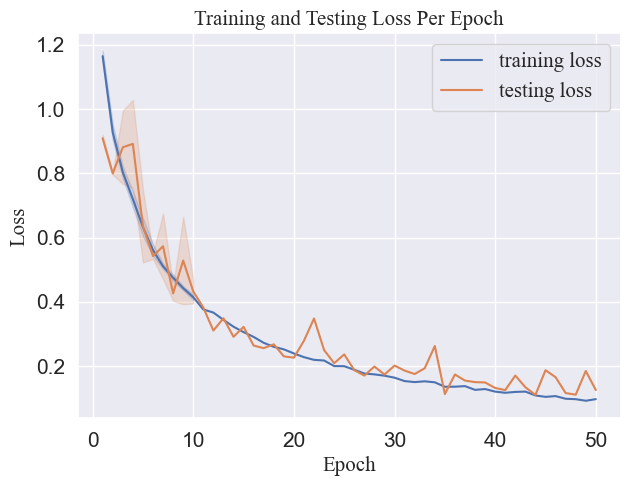

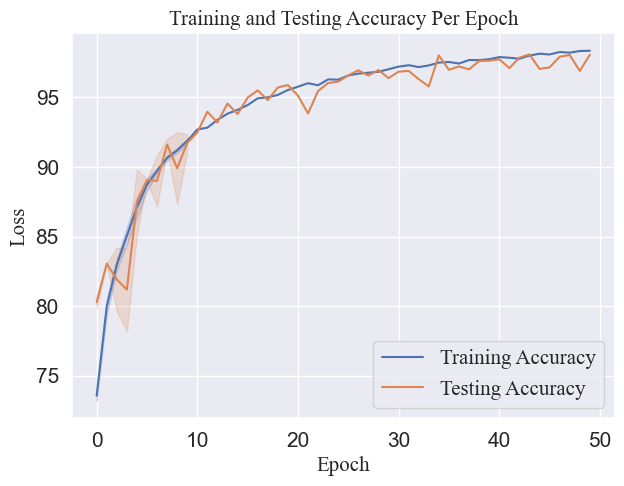

In [29]:
main_loss("../logs/batch32-epoch50-vit-no_pretrained-argumentation.out",savepath="../figs/loss.png",title='Training and Testing Loss Per Epoch')
# Call the function with the data
main_acc("../logs/batch32-epoch50-vit-no_pretrained-argumentation.out",savepath="../figs/acc.png",title='Training and Testing Accuracy Per Epoch')

50
this is testing loss [0.9738, 0.7495, 0.8975, 0.6488, 0.6814, 0.7684, 0.4692, 0.3445, 0.4786, 0.3698, 0.3759, 0.2999, 0.359, 0.2837, 0.2907, 0.2431, 0.2453, 0.1988, 0.2147, 0.22, 0.4099, 0.2099, 0.4721, 0.2254, 0.241, 0.1621, 0.2078, 0.1372, 0.1738, 0.1628, 0.129, 0.1445, 0.1112, 0.1216, 0.1329, 0.1602, 0.1179, 0.1115, 0.1394, 0.1176, 0.1283, 0.1177, 0.0881, 0.0937, 0.1019, 0.105, 0.1103, 0.0852, 0.1113, 0.2358]


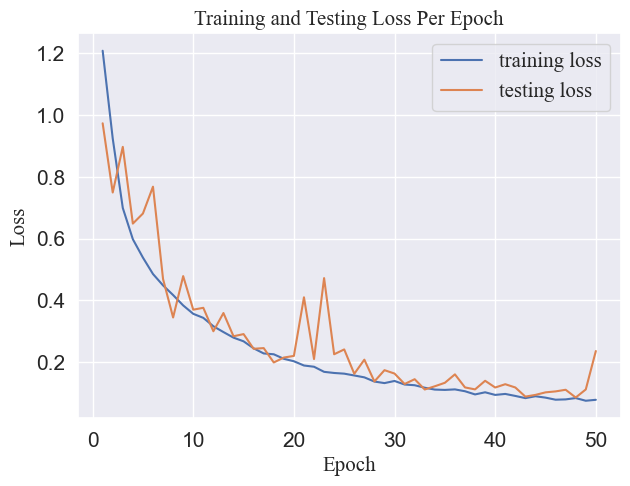

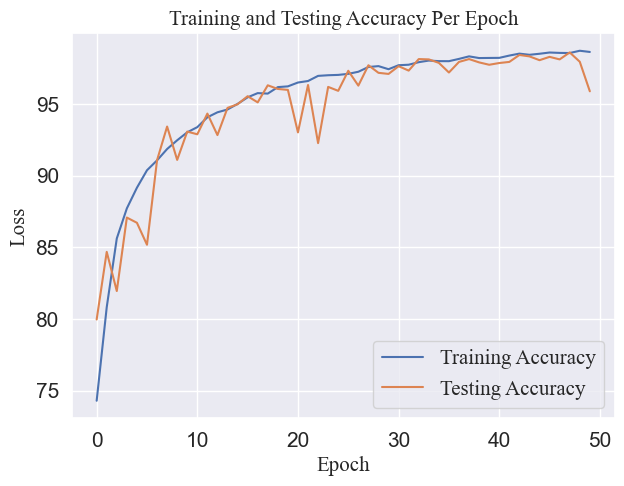

In [30]:
main_loss("../logs/batch8-epoch50-vit-no_pretrained-no-argumentation.out",savepath="../figs/loss_no.png",title='Training and Testing Loss Per Epoch')
# Call the function with the data
main_acc("../logs/batch8-epoch50-vit-no_pretrained-no-argumentation.out",savepath="../figs/acc_no.png",title='Training and Testing Accuracy Per Epoch')